This notebook implements a Personal Diary Tracker using sentiment analysis. Each diary entry is analyzed using a pretrained Transformer model to determine whether the sentiment is positive or negative. The polarity scores are plotted over a week to visualize emotional trends.

In [1]:
from transformers import pipeline
import matplotlib.pyplot as plt

C:\Users\Meghana Veeramallu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


*Load Sentiment Model*

In [2]:
sentiment_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    framework="pt"
)

Device set to use cpu


*Enter Weekly Diary Entries*

In [3]:
diary_entries = {
    "Monday": "I felt productive and completed my assignments.",
    "Tuesday": "The day was stressful and tiring.",
    "Wednesday": "I enjoyed spending time with my friends.",
    "Thursday": "I felt bored and unmotivated.",
    "Friday": "Had a great day and felt very happy.",
    "Saturday": "Relaxed and watched movies.",
    "Sunday": "Feeling hopeful and ready for next week."
}

*Analyze Sentiments*

In [4]:
mood_scores = {}

for day, entry in diary_entries.items():
    result = sentiment_analyzer(entry)[0]
    mood_scores[day] = result["score"] if result["label"] == "POSITIVE" else -result["score"]
    print(day, "->", result["label"], round(result["score"], 2))

Monday -> POSITIVE 1.0
Tuesday -> NEGATIVE 1.0
Wednesday -> POSITIVE 1.0
Thursday -> NEGATIVE 1.0
Friday -> POSITIVE 1.0
Saturday -> POSITIVE 1.0
Sunday -> POSITIVE 1.0


*Plot Mood Graph*

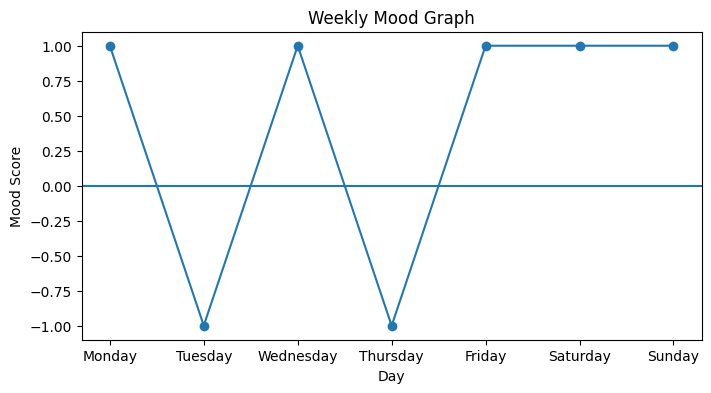

In [5]:
days = list(mood_scores.keys())
scores = list(mood_scores.values())

plt.figure(figsize=(8,4))
plt.plot(days, scores, marker='o')
plt.axhline(0)
plt.title("Weekly Mood Graph")
plt.xlabel("Day")
plt.ylabel("Mood Score")
plt.show()

The Personal Diary Tracker successfully converts textual diary entries into quantitative mood scores using sentiment analysis. The mood graph helps users understand emotional changes over time and promotes self-awareness.